# Baseline Reproduction
github: https://github.com/rohitgandikota/erasing

# Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT_DIR = 'YOUR_PROJECT_DIRECTORY'
os.makedirs(f'{PROJECT_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/images/original', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/images/erased', exist_ok=True)

In [ ]:
# Clone the ESD repo
!git clone https://github.com/rohitgandikota/erasing.git
%cd erasing

Cloning into 'erasing'...
remote: Enumerating objects: 410, done.
remote: Counting objects: 100% (126/126), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 410 (delta 96), reused 85 (delta 67), pack-reused 284 (from 3)
Receiving objects: 100% (410/410), 10.98 MiB | 38.65 MiB/s, done.
Resolving deltas: 100% (169/169), done.
/content/erasing


In [ ]:
!pip install -r requirements.txt -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 138.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 119.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 124.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 139.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/36

In [ ]:
# Verify GPU is available
import torch
print(f'CUDA available: {torch.cuda.is_available()}')

CUDA available: True


# Train ESD Model (Erase Van Gogh)

This fine-tunes the cross-attention layers of SD v1.4 to erase "Van Gogh" style.

**Method:** `esd-x` (cross-attention only)


In [ ]:
# # Run the erasure training
# !python esd_sd.py \
#     --erase_concept "Van Gogh" \
#     --train_method "esd-x" \
#     --iterations 200 \
#     --save_path "esd-models/sd/"

In [ ]:
!pip uninstall torch_xla -y -q

In [ ]:
!cd /content/erasing
!python esd_sd.py \
    --erase_concept "Van Gogh" \
    --train_method "esd-x" \
    --iterations 200 \
    --save_path "esd-models/sd/"

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
model_index.json: 100% 541/541 [00:00<00:00, 3.15MB/s]
Fetching 16 files: 100% 16/16 [00:15<00:00,  1.05it/s]
Download complete: : 5.48GB [00:15, 439MB/s]              
Loading pipeline components...:   0% 0/7 [00:00<?, ?it/s]

Loading weights: 100% 196/196 [00:00<00:00, 3110.39it/s]

Loading pipeline components...:  14% 1/7 [00:00<00:01,  5.67it/s]
Download complete: : 5.48GB [00:16, 335MB/s]
Loading weights: 100% 396/396 [00:00<00:00, 2467.67it/s]

Loading pipeline components...:  71% 5/7 [00:01<00:00,  3.06it/s]
Loading pipeline components...: 100% 7/7 [00:01<00:00,  4.40it/s]
Training ESD (sd): 100% 200/200 [1:28:42<00:00, 26.61s/it, esd_loss=0.0001, timestep=8]
Saved checkpoint to esd-mod

In [ ]:
import glob
import shutil

checkpoints = glob.glob('/content/erasing/esd-models/sd/*.safetensors')
print('Saved checkpoints:')
for cp in checkpoints:
    print(f'  {cp}')
    shutil.copy(cp, f'{PROJECT_DIR}/checkpoints/')
    print(f'  -> Copied to Google Drive')

CHECKPOINT_PATH = checkpoints[0]
print(f'\nUsing checkpoint: {CHECKPOINT_PATH}')

Saved checkpoints:
  /content/erasing/esd-models/sd/esd-Van_Gogh-from-Van_Gogh-esdx.safetensors
  -> Copied to Google Drive

Using checkpoint: /content/erasing/esd-models/sd/esd-Van_Gogh-from-Van_Gogh-esdx.safetensors


# Generate Images — Original Model vs Erased Model

We generate images using the Van Gogh prompts that come with the repo.
Same seeds are used for both models so comparisons are fair.

In [ ]:
!pip install Pillow==11.1.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 47.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.


In [ ]:
!pip install numpy==2.0.2 scipy==1.13.1 transformers==4.51.3 diffusers==0.32.2 accelerate==1.6.0 safetensors==0.5.3 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 712.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 126.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 107.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires 

In [ ]:
import torch
import pandas as pd
from diffusers import StableDiffusionPipeline
from safetensors.torch import load_file
from copy import deepcopy
from PIL import Image
import matplotlib.pyplot as plt

torch.set_grad_enabled(False)

# Load the base pipeline
device = 'cuda:0'
torch_dtype = torch.bfloat16

pipe = StableDiffusionPipeline.from_pretrained(
    'CompVis/stable-diffusion-v1-4',
    torch_dtype=torch_dtype,
    use_safetensors=True,
    safety_checker=None
).to(device)

# Save a copy of original weights
original_weights = deepcopy(pipe.unet.state_dict())

# Load erased weights
esd_weights = load_file(CHECKPOINT_PATH)

print('Pipeline loaded successfully!')
print(f'ESD checkpoint keys: {len(esd_weights)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Pipeline loaded successfully!
ESD checkpoint keys: 80


In [ ]:
# Load the Van Gogh prompts
prompts_df = pd.read_csv('/content/erasing/data/vangogh_prompts.csv')
print(f'Total prompts: {len(prompts_df)}')
print(f'\nFirst 5 prompts:')
for _, row in prompts_df.head().iterrows():
    print(f'  [{row.case_number}] {row.prompt} (seed: {row.evaluation_seed})')

Total prompts: 50

First 5 prompts:
  [0] A Wheatfield, with Cypresses by Vincent van Gogh (seed: 2219)
  [1] Almond Blossoms by Vincent van Gogh (seed: 4965)
  [2] Bedroom in Arles by Vincent van Gogh (seed: 2795)
  [3] Bridge at Trinquetaille by Vincent van Gogh (seed: 3370)
  [4] Café Terrace at Night by Vincent van Gogh (seed: 2776)


In [ ]:
def generate_image(pipe, prompt, seed, device='cuda:0'):
    """Generate a single image with a fixed seed for reproducibility."""
    generator = torch.Generator(device=device).manual_seed(seed)
    image = pipe(
        prompt,
        generator=generator,
        num_inference_steps=50,
        guidance_scale=7.5
    ).images[0]
    return image


def switch_to_original(pipe, original_weights):
    """Load original SD weights back into the pipeline."""
    pipe.unet.load_state_dict(original_weights)


def switch_to_erased(pipe, original_weights, esd_weights):
    """Load erased ESD weights into the pipeline."""
    pipe.unet.load_state_dict(original_weights)  # reset first
    pipe.unet.load_state_dict(esd_weights, strict=False)  # apply ESD changes

In [ ]:
# Generate images for a subset of prompts (first 10 for quick results)
# You can increase NUM_PROMPTS to generate all 50 later
NUM_PROMPTS = 10

print(f'Generating {NUM_PROMPTS} image pairs (original vs erased)...\n')

for _, row in prompts_df.head(NUM_PROMPTS).iterrows():
    case_num = int(row.case_number)
    prompt = str(row.prompt)
    seed = int(row.evaluation_seed)

    print(f'[{case_num}] {prompt[:60]}...')

    # Generate with ORIGINAL model
    switch_to_original(pipe, original_weights)
    img_original = generate_image(pipe, prompt, seed)
    img_original.save(f'{PROJECT_DIR}/images/original/{case_num}.png')

    # Generate with ERASED model
    switch_to_erased(pipe, original_weights, esd_weights)
    img_erased = generate_image(pipe, prompt, seed)
    img_erased.save(f'{PROJECT_DIR}/images/erased/{case_num}.png')

# print(f'\nDone. Images saved to {PROJECT_DIR}/images/')

Generating 10 image pairs (original vs erased)...

[0] A Wheatfield, with Cypresses by Vincent van Gogh...


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

[1] Almond Blossoms by Vincent van Gogh...


  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

[9] Green Wheat Field with Cypress by Vincent van Gogh...


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

# Visual Comparison Grid
Side-by-side comparison of original vs erased model outputs.

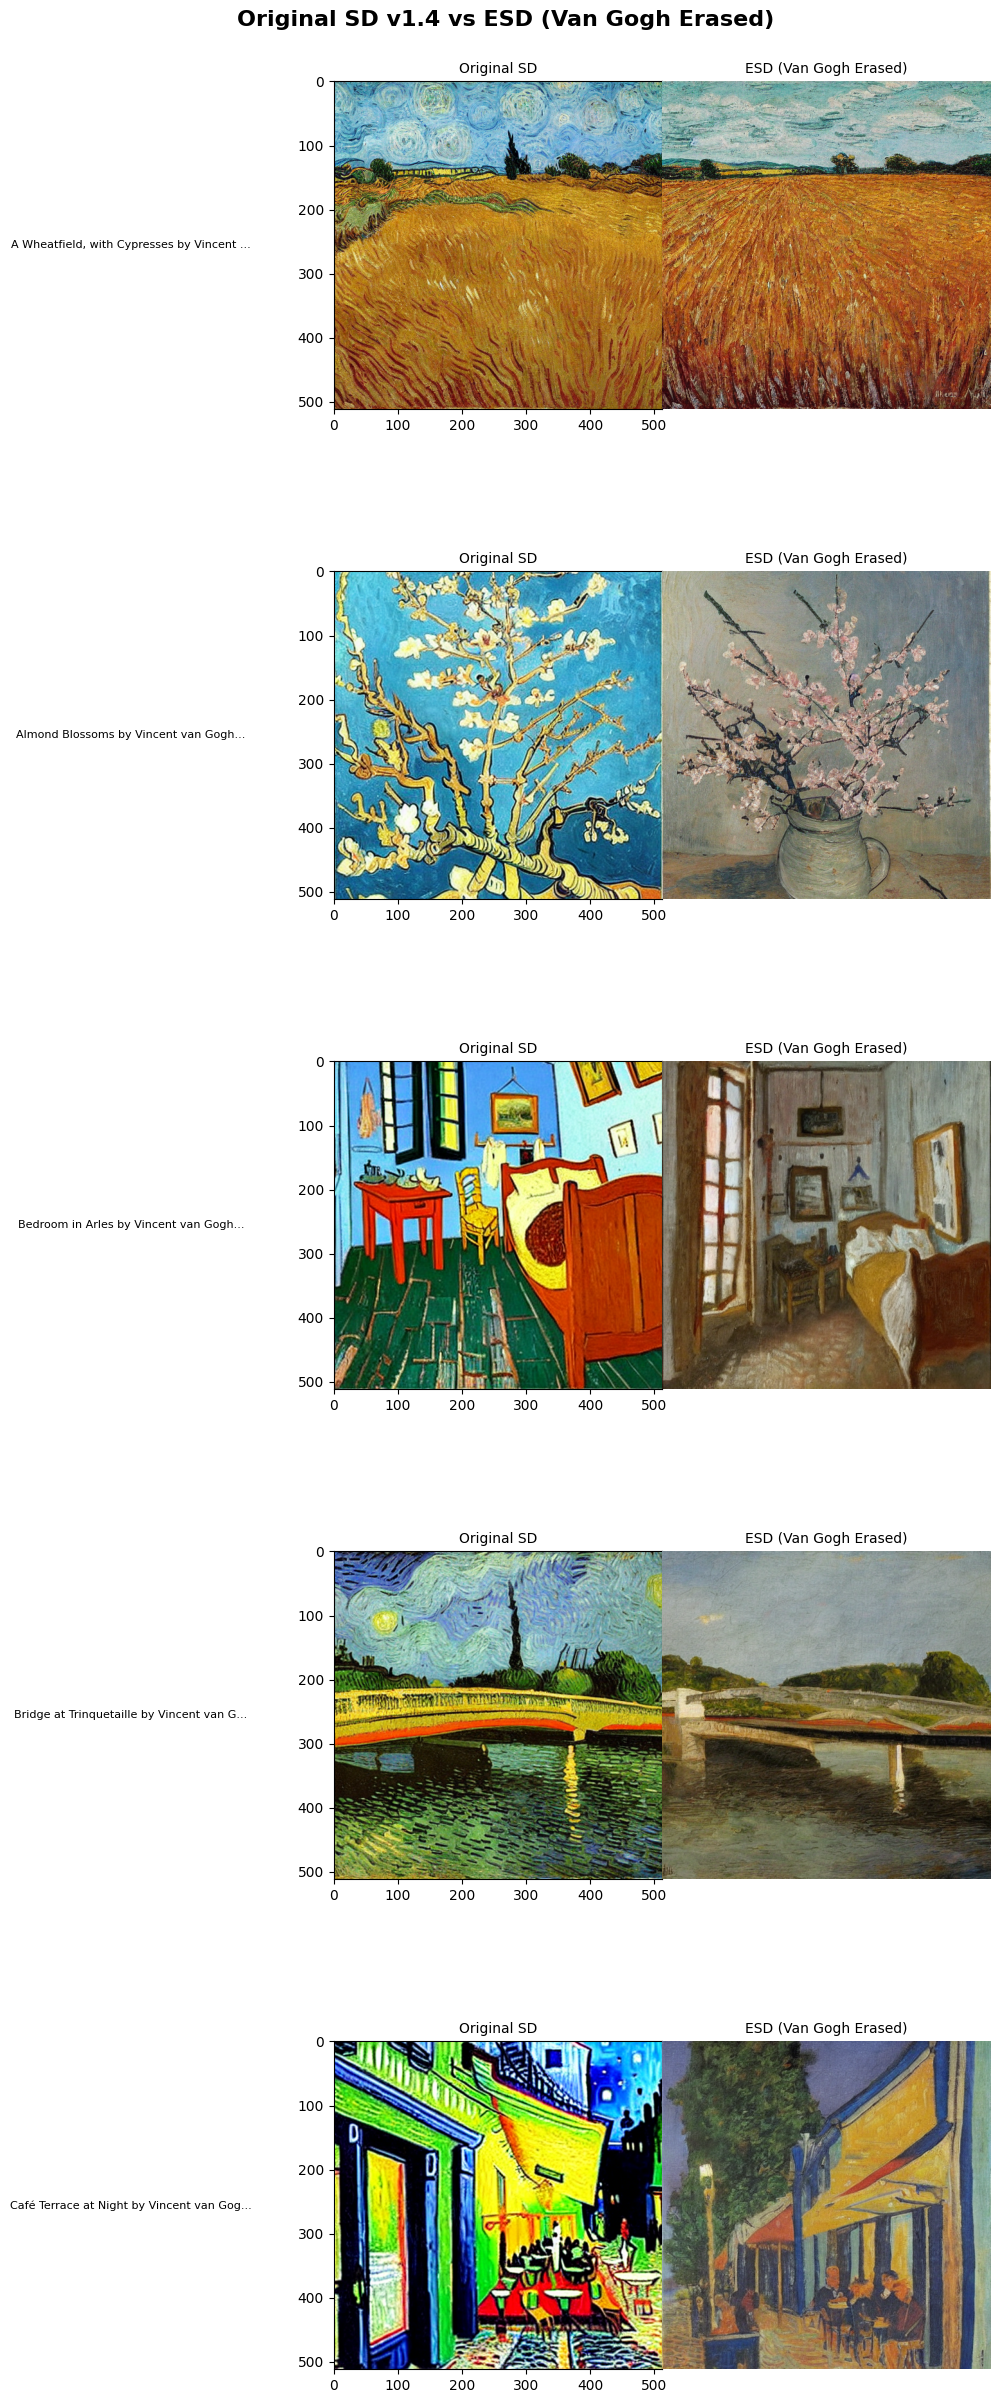

In [ ]:
# Display comparison grid
num_display = min(NUM_PROMPTS, 5)  # show first 5

fig, axes = plt.subplots(num_display, 2, figsize=(10, 5 * num_display))
fig.suptitle('Original SD v1.4 vs ESD (Van Gogh Erased)', fontsize=16, fontweight='bold')

for i in range(num_display):
    row = prompts_df.iloc[i]
    case_num = int(row.case_number)
    prompt = str(row.prompt)

    img_orig = Image.open(f'{PROJECT_DIR}/images/original/{case_num}.png')
    img_erase = Image.open(f'{PROJECT_DIR}/images/erased/{case_num}.png')

    axes[i, 0].imshow(img_orig)
    axes[i, 0].set_title('Original SD', fontsize=10)
    # Add prompt as row label
    axes[i, 0].set_ylabel(prompt[:40] + '...', fontsize=8, rotation=0, labelpad=120, va='center')

    axes[i, 1].imshow(img_erase)
    axes[i, 1].set_title('ESD (Van Gogh Erased)', fontsize=10)
    axes[i, 1].axis('off')


plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/comparison_grid.png', dpi=150, bbox_inches='tight')
plt.show()
# print(f'Grid saved to {PROJECT_DIR}/comparison_grid.png')

# Generate All 50 Prompts (Full Run)
To generate the complete dataset.

In [ ]:
for _, row in prompts_df.iterrows():
     case_num = int(row.case_number)
     prompt = str(row.prompt)
     seed = int(row.evaluation_seed)

     # Skip if already generated
     if os.path.exists(f'{PROJECT_DIR}/images/original/{case_num}.png'):
         continue

     print(f'[{case_num}/49] {prompt[:50]}...')

     switch_to_original(pipe, original_weights)
     img_original = generate_image(pipe, prompt, seed)
     img_original.save(f'{PROJECT_DIR}/images/original/{case_num}.png')

     switch_to_erased(pipe, original_weights, esd_weights)
     img_erased = generate_image(pipe, prompt, seed)
     img_erased.save(f'{PROJECT_DIR}/images/erased/{case_num}.png')

print('All 50 prompts generated!')

# Generate Non-Van-Gogh Images (Sanity Check)
Verify that the erased model still generates good images for other styles.

In [ ]:
# Test prompts for other artists (sanity check that erasure doesn't break everything)
sanity_prompts = [
    'A water lily pond by Claude Monet',
    'A cubist portrait by Pablo Picasso',
    'A Campbell soup can by Andy Warhol',
    'A beautiful sunset over the ocean, oil painting',
    'A photograph of a golden retriever in a park',
]

os.makedirs(f'{PROJECT_DIR}/images/sanity_original', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/images/sanity_erased', exist_ok=True)

seed = 42  # fixed seed for all sanity checks

fig, axes = plt.subplots(len(sanity_prompts), 2, figsize=(10, 5 * len(sanity_prompts)))
fig.suptitle('Sanity Check: Other Styles Should Be Unaffected', fontsize=16, fontweight='bold')

for i, prompt in enumerate(sanity_prompts):
    print(f'Sanity check [{i+1}/{len(sanity_prompts)}]: {prompt}')

    switch_to_original(pipe, original_weights)
    img_orig = generate_image(pipe, prompt, seed)
    img_orig.save(f'{PROJECT_DIR}/images/sanity_original/{i}.png')

    switch_to_erased(pipe, original_weights, esd_weights)
    img_erased = generate_image(pipe, prompt, seed)
    img_erased.save(f'{PROJECT_DIR}/images/sanity_erased/{i}.png')

    axes[i, 0].imshow(img_orig)
    axes[i, 0].set_title('Original', fontsize=10)
    axes[i, 0].set_ylabel(prompt[:35] + '...', fontsize=8, rotation=0, labelpad=100, va='center')

    axes[i, 1].imshow(img_erased)
    axes[i, 1].set_title('Erased', fontsize=10)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/sanity_check_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSanity check grid saved to {PROJECT_DIR}/sanity_check_grid.png')